# Notebook 07: Pembuktian Kinerja V2 — Untuk Bimbingan

**Tujuan Notebook ini** adalah menjawab 3 pertanyaan kritis dari Pak Jasman:

1. **Validasi Urutan Sekuens (Sequence Labeling):** Apakah model membaca gerakan secara kronologis frame-demi-frame, bukan sekadar agregasi?
2. **Evaluasi Kinerja Per-Frame (Confusion Matrix):** Seberapa akurat model mendeteksi frame salah *tepat di frame terjadinya* kesalahan?
3. **Integritas Atensi Spasial:** Sendi mana yang *paling diperhatikan* oleh model saat memutuskan gerakan itu salah?

---

**Arsitektur Model:**
- Input : `(B, 64, 33, 3)` — 64 frame sekuensial, 33 sendi, koordinat X/Y/Z
- Output: `(B, 64, 2)`   — Logit prediksi per-frame (bukan per-video)
- Global Average Pooling **DIHAPUS** → model tidak kehilangan informasi waktu

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, f1_score

from src.data.v2.dataset import create_dataloaders_v2, PerFrameDataset
from src.models.v2.model_per_frame import AttentiveSkel3DPerFrame

# Konfigurasi Visual
plt.rcParams['figure.facecolor'] = '#0f172a'
plt.rcParams['axes.facecolor']   = '#1e293b'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['axes.edgecolor']   = '#334155'
plt.rcParams['grid.color']       = '#1e293b'
plt.rcParams['font.family']      = 'DejaVu Sans'

NAMA_SENDI_33 = [
    'Nose', 'Left_Eye_Inner', 'Left_Eye', 'Left_Eye_Outer',
    'Right_Eye_Inner', 'Right_Eye', 'Right_Eye_Outer',
    'Left_Ear', 'Right_Ear', 'Mouth_Left', 'Mouth_Right',
    'Left_Shoulder', 'Right_Shoulder',
    'Left_Elbow', 'Right_Elbow',
    'Left_Wrist', 'Right_Wrist',
    'Left_Pinky', 'Right_Pinky',
    'Left_Index', 'Right_Index',
    'Left_Thumb', 'Right_Thumb',
    'Left_Hip', 'Right_Hip',
    'Left_Knee', 'Right_Knee',
    'Left_Ankle', 'Right_Ankle',
    'Left_Heel', 'Right_Heel',
    'Left_Foot_Index', 'Right_Foot_Index',
]

MANIFEST_PATH = PROJECT_ROOT / 'data' / 'processed' / 'manifest_v2.csv'
MODELS_DIR    = PROJECT_ROOT / 'models' / 'saved_models' / 'v2'
device        = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f'Device  : {device}')
print(f'Project : {PROJECT_ROOT}')

Device  : cuda
Project : D:\Data-Aji\KULIAH\Tugas-Akhir\AttentiveSkel3D-WeightTraining-PoC


In [2]:
def load_model(model_name: str):
    """Muat model .pth dan deteksi fitur atensi secara otomatis."""
    model_path = MODELS_DIR / model_name
    checkpoint = torch.load(model_path, map_location=device)
    state_dict = checkpoint.get('model_state_dict', checkpoint)

    use_sp = any(k.startswith('biomechanical_spatial_prior') for k in state_dict)
    use_ls = any(k.startswith('learned_spatial_attention')   for k in state_dict)
    use_ta = any(k.startswith('temporal_attention')           for k in state_dict)

    model = AttentiveSkel3DPerFrame(num_classes=2,
                                    use_spatial_prior=use_sp,
                                    use_learned_spatial=use_ls,
                                    use_temporal_attention=use_ta)
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    print(f'Model     : {model_name}')
    print(f'BSP       : {"Aktif" if use_sp else "Nonaktif"} | '
          f'LSA : {"Aktif" if use_ls else "Nonaktif"} | '
          f'TA  : {"Aktif" if use_ta else "Nonaktif"}')
    return model, use_sp

# Gunakan model full (bisa diubah ke ablasi)
MODEL_NAME = 'best_model_full.pth'
model, has_bsp = load_model(MODEL_NAME)

Model     : best_model_full.pth
BSP       : Aktif | LSA : Aktif | TA  : Aktif


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34420\878645988.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=devi

---
## Bagian 1: Validasi Urutan Sekuens (Sequence Labeling)

**Pertanyaan Pak Jasman:** *"Saya tidak ingin hanya tahu 55 frame benar dan 9 frame salah. Saya ingin lihat urutan kejadiannya secara kronologis."*

Di bawah ini, kita ambil **satu sampel video** dari Test Set, lalu bandingkan:
- **Baris Atas (Biru):** Ground Truth dari sistem labeling biomekanika
- **Baris Bawah (Merah/Hijau):** Prediksi AI frame-per-frame

Jika model bekerja benar, pola warna pada kedua baris harus **sangat mirip**.

Dataset split selesai (seed=42):
  Train  :  340 sampel → 21 batch
  Val    :   73 sampel → 5 batch
  Test   :   74 sampel → 5 batch


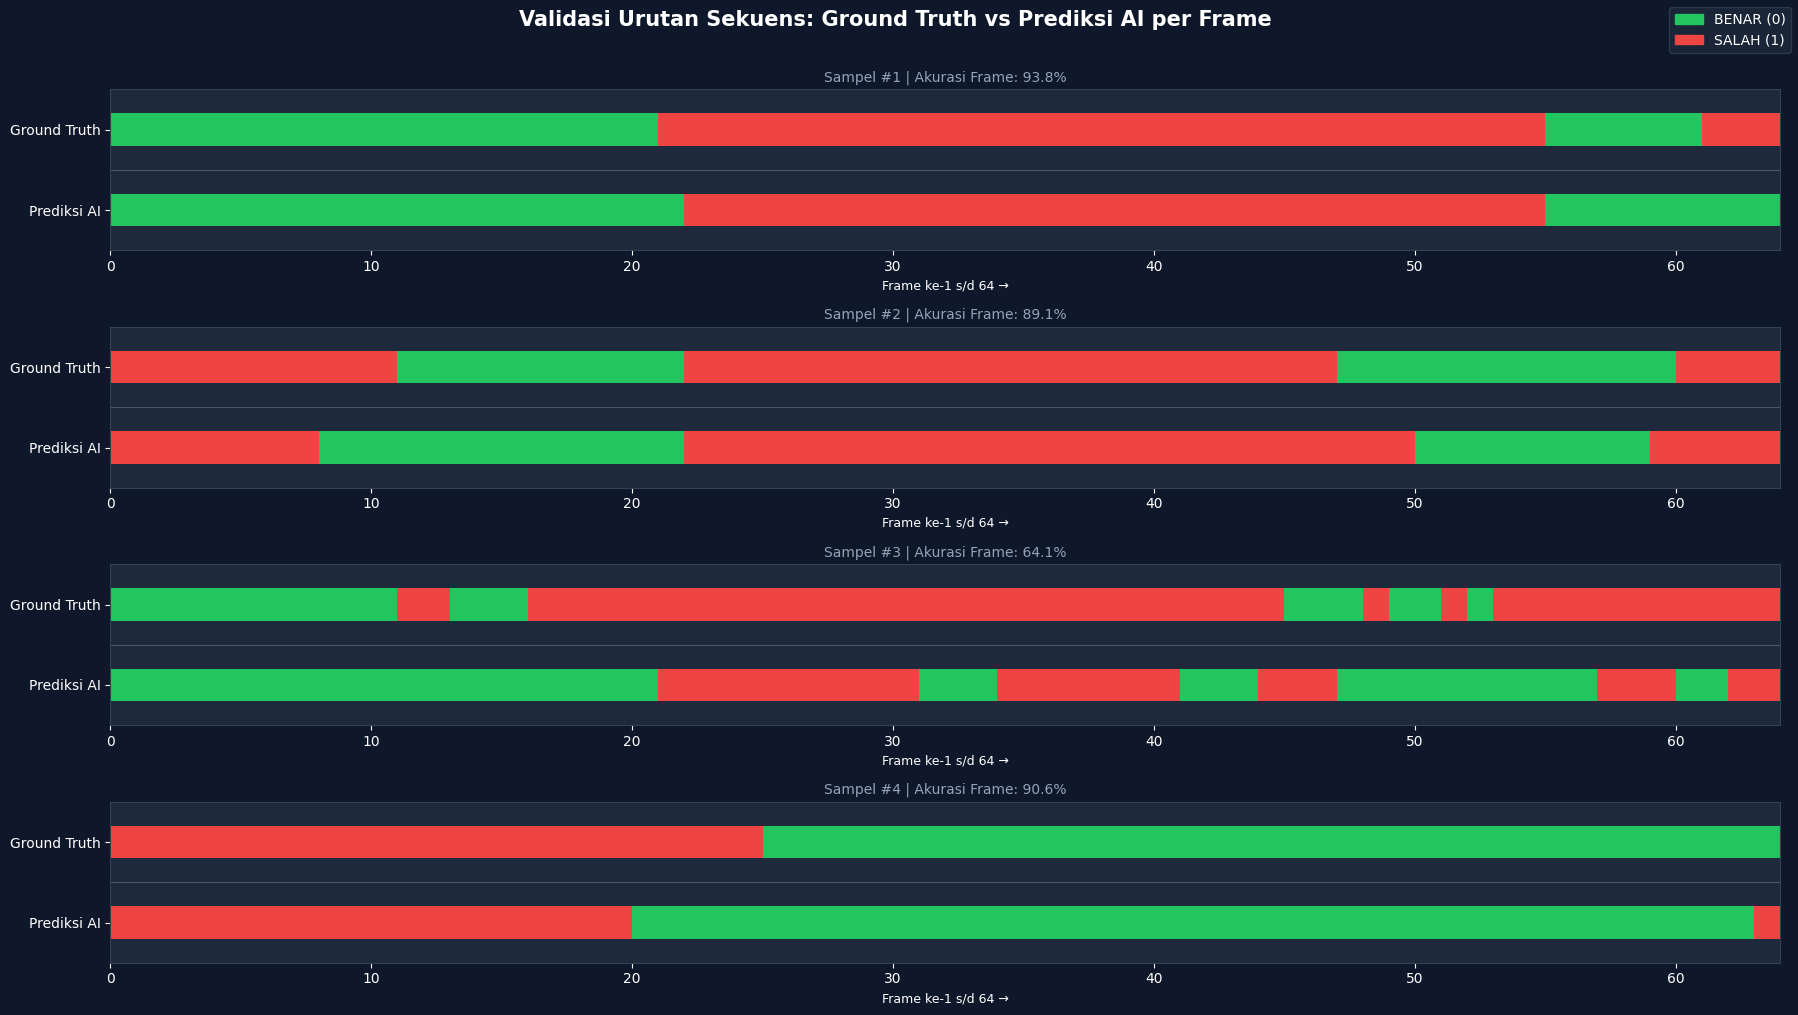

Grafik disimpan ke: data/processed/viz_sequence_labeling.png


In [3]:
# Ambil test set
_, _, test_loader = create_dataloaders_v2(
    csv_file=MANIFEST_PATH, batch_size=16, train_ratio=0.70,
    val_ratio=0.15, random_seed=42
)

# Ambil batch pertama
batch_input, batch_labels = next(iter(test_loader))

with torch.no_grad():
    logits = model(batch_input.to(device))   # (B, 64, 2)
    preds  = logits.argmax(dim=2)            # (B, 64)

# Pilih 4 sampel untuk divisualisasikan
N_SAMPEL = min(4, batch_input.shape[0])

fig, axes = plt.subplots(N_SAMPEL, 1, figsize=(18, N_SAMPEL * 2.5))
fig.suptitle('Validasi Urutan Sekuens: Ground Truth vs Prediksi AI per Frame',
             fontsize=15, fontweight='bold', color='white', y=1.01)

for i in range(N_SAMPEL):
    ax = axes[i] if N_SAMPEL > 1 else axes
    gt   = batch_labels[i].numpy()   # (64,)
    pred = preds[i].cpu().numpy()    # (64,)
    frames = np.arange(1, 65)

    # Ground Truth bar — dua baris: atas GT, bawah Pred
    height = 0.4
    for f in range(64):
        c_gt   = '#ef4444' if gt[f]   == 1 else '#22c55e'
        c_pred = '#ef4444' if pred[f] == 1 else '#22c55e'

        ax.barh(1.5, 1, left=f, height=height, color=c_gt,   align='center', linewidth=0)
        ax.barh(0.5, 1, left=f, height=height, color=c_pred, align='center', linewidth=0)

    # Hitung akurasi sampel ini
    acc_i = (gt == pred).mean() * 100

    ax.set_xlim(0, 64)
    ax.set_ylim(0, 2)
    ax.set_yticks([0.5, 1.5])
    ax.set_yticklabels(['Prediksi AI', 'Ground Truth'], fontsize=10)
    ax.set_xlabel('Frame ke-1 s/d 64 →', fontsize=9)
    ax.set_title(f'Sampel #{i+1} | Akurasi Frame: {acc_i:.1f}%', fontsize=10, color='#94a3b8')

    # Garis pemisah
    ax.axhline(y=1.0, color='white', linewidth=0.5, alpha=0.3)

# Legend
patch_benar = mpatches.Patch(color='#22c55e', label='BENAR (0)')
patch_salah = mpatches.Patch(color='#ef4444', label='SALAH (1)')
fig.legend(handles=[patch_benar, patch_salah], loc='upper right',
           facecolor='#1e293b', edgecolor='#334155', labelcolor='white')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/viz_sequence_labeling.png',
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('Grafik disimpan ke: data/processed/viz_sequence_labeling.png')

---
## Bagian 2: Evaluasi Kinerja Per-Frame (Confusion Matrix)

**Pertanyaan Pak Jasman:** *"Seberapa tepat model mendeteksi frame salah *di frame terjadinya*? Bukan sekadar akurasi rata-rata."*

Kita evaluasi seluruh Test Set dan tampilkan:
- **Confusion Matrix** (heatmap warna)
- **Tabel Metrik:** Precision, Recall, F1-Score untuk kelas BENAR dan SALAH

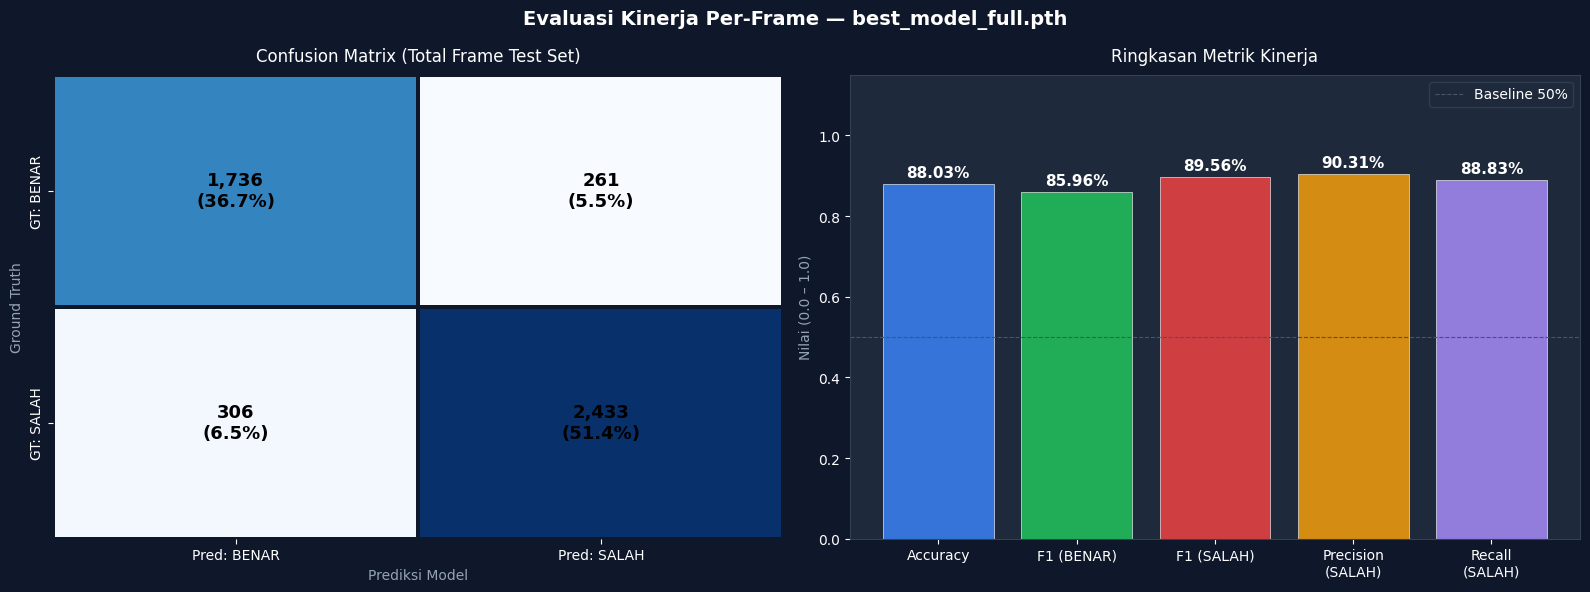

Total frame dievaluasi : 4,736
TP=2,433 TN=1,736 FP=261 FN=306
              precision    recall  f1-score   support

   BENAR (0)       0.85      0.87      0.86      1997
   SALAH (1)       0.90      0.89      0.90      2739

    accuracy                           0.88      4736
   macro avg       0.88      0.88      0.88      4736
weighted avg       0.88      0.88      0.88      4736



In [4]:
# Forward pass seluruh test set
all_preds, all_truths = [], []

with torch.no_grad():
    for batch_input, batch_labels in test_loader:
        logits = model(batch_input.to(device))    # (B, 64, 2)
        preds_b = logits.argmax(dim=2)            # (B, 64)
        all_preds.extend(preds_b.cpu().numpy().flatten())
        all_truths.extend(batch_labels.numpy().flatten())

all_preds  = np.array(all_preds)
all_truths = np.array(all_truths)

# Confusion Matrix
cm = confusion_matrix(all_truths, all_preds)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Evaluasi Kinerja Per-Frame — {MODEL_NAME}',
             fontsize=14, fontweight='bold', color='white')

# --- Plot 1: Heatmap Confusion Matrix ---
ax1 = axes[0]
cm_pct = cm.astype(float) / cm.sum() * 100
annot  = np.array([[f'{cm[r,c]:,}\n({cm_pct[r,c]:.1f}%)' for c in range(2)] for r in range(2)])

cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', ax=ax1,
            xticklabels=['Pred: BENAR', 'Pred: SALAH'],
            yticklabels=['GT: BENAR', 'GT: SALAH'],
            linewidths=1.5, linecolor='#0f172a',
            annot_kws={'size': 13, 'weight': 'bold', 'color': 'black'},
            cbar=False)

ax1.set_title('Confusion Matrix (Total Frame Test Set)', color='white', pad=10)
ax1.set_xlabel('Prediksi Model', color='#94a3b8')
ax1.set_ylabel('Ground Truth', color='#94a3b8')

# --- Plot 2: Bar Metrik ---
ax2 = axes[1]
acc = (all_preds == all_truths).mean()
f1_b  = f1_score(all_truths, all_preds, pos_label=0)
f1_s  = f1_score(all_truths, all_preds, pos_label=1)
prec_s = tp / (tp + fp) if (tp + fp) > 0 else 0
rec_s  = tp / (tp + fn) if (tp + fn) > 0 else 0

labels  = ['Accuracy', 'F1 (BENAR)', 'F1 (SALAH)', 'Precision\n(SALAH)', 'Recall\n(SALAH)']
values  = [acc, f1_b, f1_s, prec_s, rec_s]
colors  = ['#3b82f6', '#22c55e', '#ef4444', '#f59e0b', '#a78bfa']

bars = ax2.bar(labels, values, color=colors, alpha=0.85, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val*100:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold', color='white')

ax2.set_ylim(0, 1.15)
ax2.set_title('Ringkasan Metrik Kinerja', color='white', pad=10)
ax2.set_ylabel('Nilai (0.0 – 1.0)', color='#94a3b8')
ax2.axhline(y=0.5, color='#475569', linestyle='--', linewidth=0.8, label='Baseline 50%')
ax2.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/viz_confusion_matrix.png',
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print(f'Total frame dievaluasi : {len(all_truths):,}')
print(f'TP={tp:,} TN={tn:,} FP={fp:,} FN={fn:,}')
print(classification_report(all_truths, all_preds, target_names=['BENAR (0)', 'SALAH (1)']))

---
## Bagian 3: Integritas Atensi — Sendi Mana yang Paling Diperhatikan?

**Pertanyaan Pak Jasman:** *"AI tidak cuma bilang gerakan salah, tapi bisa menyorot sendi mana penyebabnya."*

Di bawah ini kita ekstrak bobot **Biomechanical Spatial Prior (BSP)** — yaitu parameter yang dipelajari model untuk menetapkan 'kepentingan' setiap sendi dari 33 sendi BlazePose.

Sendi dengan bobot mendekati 1.0 = model **sangat fokus** ke sendi ini saat mengklasifikasi gerakan.

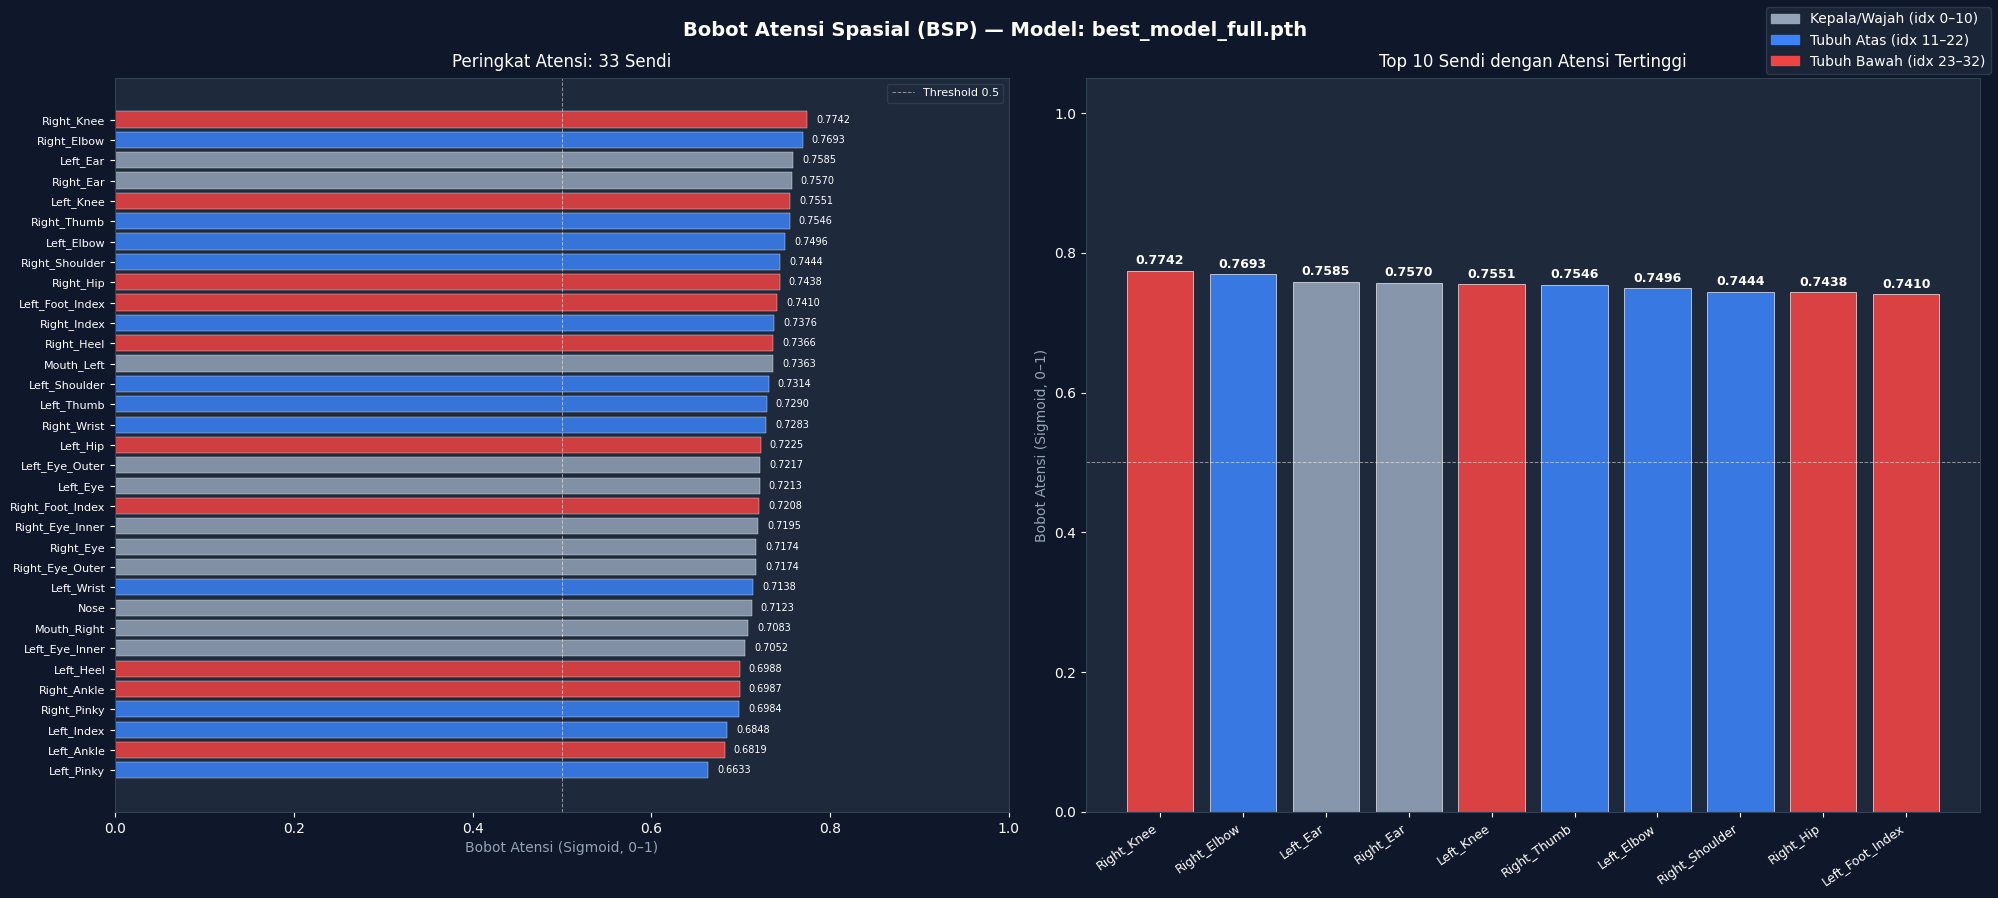

Grafik disimpan ke: data/processed/viz_attention_weights.png

Peringkat Nama Sendi                     Area         Bobot Atensi
-----------------------------------------------------------------
    1 Right_Knee                     Tubuh Bawah      0.774226
    2 Right_Elbow                    Tubuh Atas       0.769277
    3 Left_Ear                       Kepala/Wajah     0.758483
    4 Right_Ear                      Kepala/Wajah     0.757022
    5 Left_Knee                      Tubuh Bawah      0.755061
    6 Right_Thumb                    Tubuh Atas       0.754590
    7 Left_Elbow                     Tubuh Atas       0.749596
    8 Right_Shoulder                 Tubuh Atas       0.744352
    9 Right_Hip                      Tubuh Bawah      0.743752
   10 Left_Foot_Index                Tubuh Bawah      0.740952
   11 Right_Index                    Tubuh Atas       0.737551
   12 Right_Heel                     Tubuh Bawah      0.736578
   13 Mouth_Left                     Kepala/Wajah

In [5]:
if not has_bsp:
    print('Model ini tidak memiliki Biomechanical Spatial Prior (model ablasi).')
    print('Ganti ke best_model_full.pth untuk melihat bobot atensi.')
else:
    bsp_raw     = model.biomechanical_spatial_prior.detach().cpu().squeeze().numpy()  # (33,)
    bsp_weights = torch.sigmoid(model.biomechanical_spatial_prior).detach().cpu().squeeze().numpy()

    # Sort descending
    order = np.argsort(bsp_weights)[::-1]
    sorted_names   = [NAMA_SENDI_33[i] for i in order]
    sorted_weights = bsp_weights[order]

    # Kelompokkan warna berdasarkan area tubuh
    body_area_color = {
        'Face/Head' : '#94a3b8',
        'Upper Body': '#3b82f6',
        'Lower Body': '#ef4444',
    }
    face_ids  = set(range(0, 11))
    upper_ids = set(range(11, 23))
    lower_ids = set(range(23, 33))

    bar_colors = []
    for i in order:
        if i in face_ids:
            bar_colors.append('#94a3b8')
        elif i in upper_ids:
            bar_colors.append('#3b82f6')
        else:
            bar_colors.append('#ef4444')

    fig, axes = plt.subplots(1, 2, figsize=(20, 9))
    fig.suptitle(f'Bobot Atensi Spasial (BSP) — Model: {MODEL_NAME}',
                 fontsize=14, fontweight='bold', color='white')

    # --- Plot 1: Bar Chart semua 33 sendi ---
    ax1 = axes[0]
    bars = ax1.barh(range(33), sorted_weights[::-1], color=bar_colors[::-1],
                    alpha=0.85, edgecolor='white', linewidth=0.3)
    ax1.set_yticks(range(33))
    ax1.set_yticklabels(sorted_names[::-1], fontsize=8)
    ax1.set_xlabel('Bobot Atensi (Sigmoid, 0–1)', color='#94a3b8')
    ax1.set_title('Peringkat Atensi: 33 Sendi', color='white', pad=8)
    ax1.axvline(x=0.5, color='white', linestyle='--', linewidth=0.7, alpha=0.5, label='Threshold 0.5')
    ax1.set_xlim(0, 1.0)
    ax1.legend(facecolor='#1e293b', edgecolor='#334155', labelcolor='white', fontsize=8)

    # Tambah nilai teks
    for i, (bar, w) in enumerate(zip(bars, sorted_weights[::-1])):
        ax1.text(w + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{w:.4f}', va='center', ha='left', fontsize=7, color='white')

    # --- Plot 2: Top 10 Sendi Paling Penting ---
    ax2 = axes[1]
    top10_names   = sorted_names[:10]
    top10_weights = sorted_weights[:10]
    top10_colors  = bar_colors[:10]

    bars2 = ax2.bar(range(10), top10_weights, color=top10_colors,
                    alpha=0.9, edgecolor='white', linewidth=0.5)
    for bar, w in zip(bars2, top10_weights):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{w:.4f}', ha='center', va='bottom', fontsize=9,
                 fontweight='bold', color='white')

    ax2.set_xticks(range(10))
    ax2.set_xticklabels(top10_names, rotation=35, ha='right', fontsize=9)
    ax2.set_ylim(0, 1.05)
    ax2.set_title('Top 10 Sendi dengan Atensi Tertinggi', color='white', pad=8)
    ax2.set_ylabel('Bobot Atensi (Sigmoid, 0–1)', color='#94a3b8')
    ax2.axhline(y=0.5, color='white', linestyle='--', linewidth=0.7, alpha=0.5)

    # Legend area tubuh
    patches = [
        mpatches.Patch(color='#94a3b8', label='Kepala/Wajah (idx 0–10)'),
        mpatches.Patch(color='#3b82f6', label='Tubuh Atas (idx 11–22)'),
        mpatches.Patch(color='#ef4444', label='Tubuh Bawah (idx 23–32)'),
    ]
    fig.legend(handles=patches, loc='upper right',
               facecolor='#1e293b', edgecolor='#334155', labelcolor='white')

    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / 'data/processed/viz_attention_weights.png',
                dpi=150, bbox_inches='tight', facecolor='#0f172a')
    plt.show()
    print('Grafik disimpan ke: data/processed/viz_attention_weights.png')

    # Tabel ringkas
    print(f'\n{"Peringkat":>5} {"Nama Sendi":30s} {"Area":12s} {"Bobot Atensi":>12s}')
    print('-' * 65)
    area_map = {i: ('Kepala/Wajah' if i < 11 else ('Tubuh Atas' if i < 23 else 'Tubuh Bawah'))
                for i in range(33)}
    for rank, (idx, nama, w) in enumerate(zip(order, sorted_names, sorted_weights), 1):
        print(f'{rank:>5} {nama:30s} {area_map[idx]:12s} {w:>12.6f}')

---
## Bagian 4 (Bonus): Perbandingan Atensi Antar Model (Full vs Ablasi)

Membuktikan bahwa setiap model ablasi memberikan profil atensi yang berbeda.

Model     : best_model_full.pth
BSP       : Aktif | LSA : Aktif | TA  : Aktif
Model     : best_model_ablasi_a.pth
BSP       : Nonaktif | LSA : Aktif | TA  : Aktif
Model     : best_model_ablasi_c.pth
BSP       : Aktif | LSA : Aktif | TA  : Nonaktif


C:\Users\Administrator\AppData\Local\Temp\ipykernel_34420\878645988.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=devi

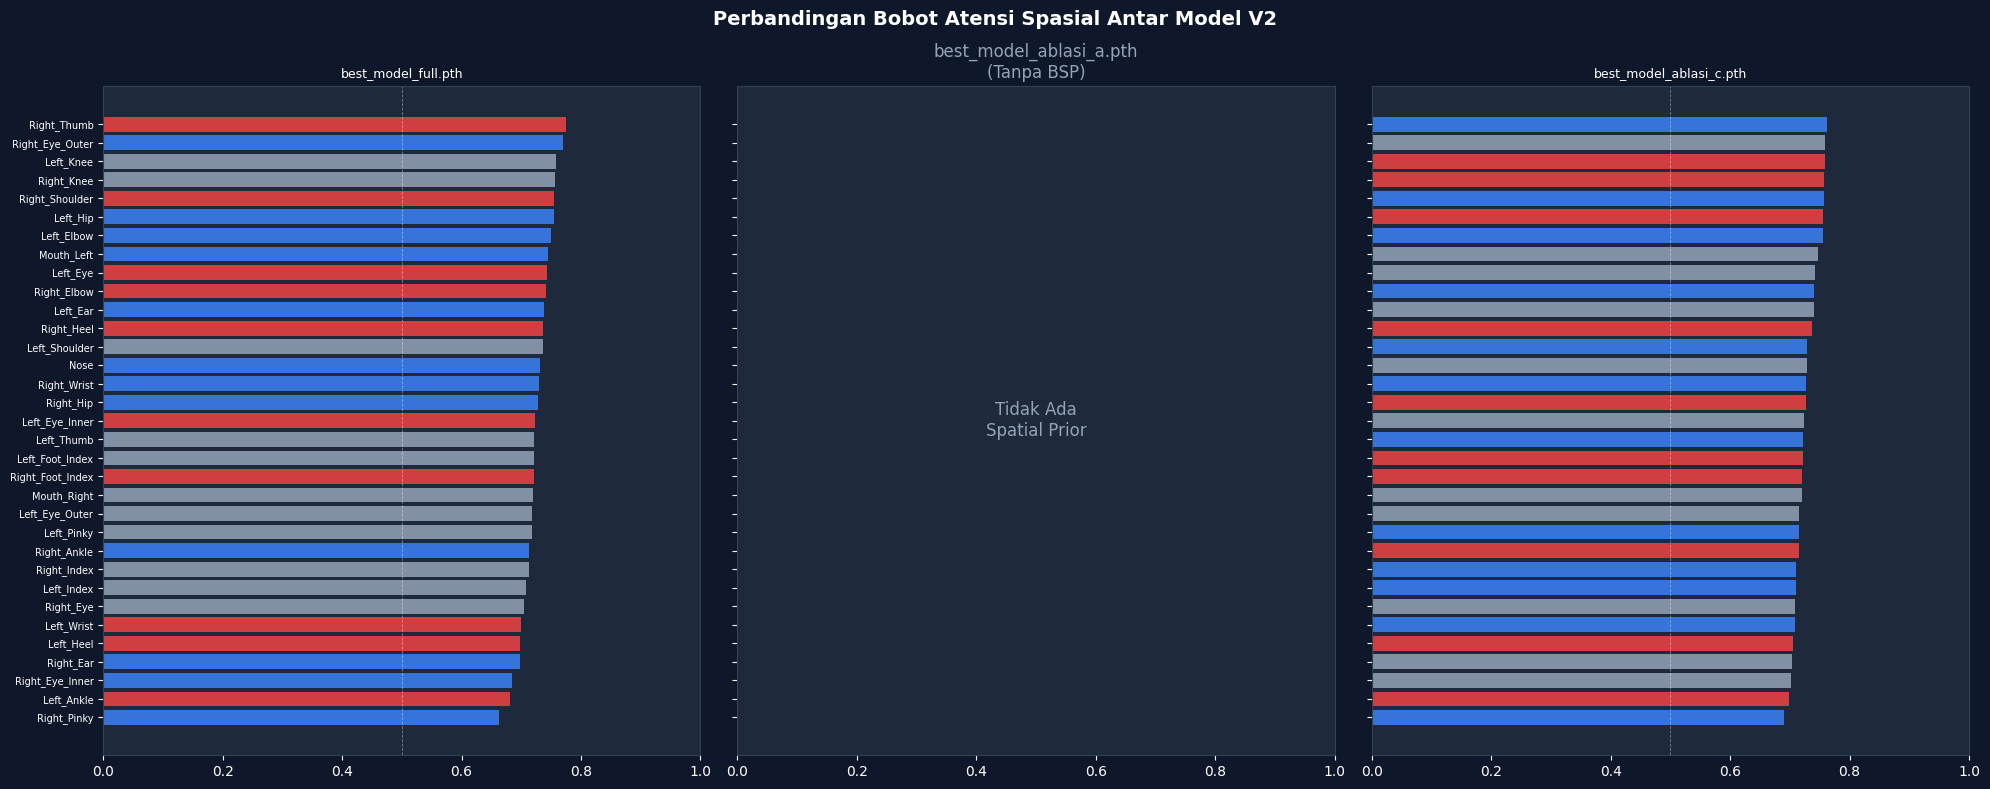

Grafik disimpan ke: data/processed/viz_attention_comparison.png


In [6]:
MODELS_TO_COMPARE = [
    'best_model_full.pth',
    'best_model_ablasi_a.pth',
    'best_model_ablasi_c.pth',
]

fig, axes = plt.subplots(1, len(MODELS_TO_COMPARE), figsize=(20, 8), sharey=True)
fig.suptitle('Perbandingan Bobot Atensi Spasial Antar Model V2',
             fontsize=14, fontweight='bold', color='white')

for ax, mname in zip(axes, MODELS_TO_COMPARE):
    m, has_b = load_model(mname)
    if not has_b:
        ax.set_title(f'{mname}\n(Tanpa BSP)', color='#94a3b8')
        ax.text(0.5, 0.5, 'Tidak Ada\nSpatial Prior', ha='center', va='center',
                transform=ax.transAxes, color='#94a3b8', fontsize=12)
        continue

    bsp = torch.sigmoid(m.biomechanical_spatial_prior).detach().cpu().squeeze().numpy()
    order = np.argsort(bsp)[::-1]

    colors = ['#ef4444' if i >= 23 else ('#3b82f6' if i >= 11 else '#94a3b8') for i in order]
    ax.barh(range(33), bsp[order][::-1], color=colors[::-1], alpha=0.85)
    ax.set_yticks(range(33))
    ax.set_yticklabels([NAMA_SENDI_33[i] for i in order][::-1], fontsize=7)
    ax.set_title(f'{mname}', color='white', fontsize=9, pad=6)
    ax.set_xlim(0, 1.0)
    ax.axvline(0.5, color='white', linestyle='--', linewidth=0.6, alpha=0.4)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'data/processed/viz_attention_comparison.png',
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print('Grafik disimpan ke: data/processed/viz_attention_comparison.png')